In [1]:
from dataclasses import dataclass
from enum import Enum
import numpy as np
from IPython.display import SVG, display

In [2]:
class BlockType(Enum):
    COLUMN = "column"
    FENCE = "fence"


@dataclass
class Block:
    length_mm: int
    width_mm: int
    height_mm: int
    mass_kg: float
    price_rub: int
    block_type: BlockType

In [3]:
@dataclass
class fenceParams:
    length_front : int = 0
    height_fence : int = 0
    height_column : int = 0

    columns_count : int = 0
    gates_length : list[int] = 0

    @property
    def gates(self):
        if self.gates_length == 0:
            return 0
        else:
            return len(self.gates_length)

In [4]:
@dataclass()
class fenceSolution:
    columns_count: int = 0                 # количество колонн
    fence_spans_count: int = 0             # количество пролетов
    spans_length: int = 0                  # длина пролета

    column_blocks_per_column: int = 0      # количество блоков в колонне

    fence_blocks_per_row_y: int = 0        # количество блоков в пролете в длину
    fence_blocks_per_row_x: int = 0        # количество блоков в пролете в высоту

    fence_blocks_per_row_x_cutted: int = 0 # количество подрезанных блоков в пролете в длину
    cutted_block_length: float = .0        # длина подрезанного блока

    error : bool = False

    def count(self):

        self.column_blocks = self.column_blocks_per_column*self.columns_count
        self.fence_blocks = int(self.fence_blocks_per_row_y*self.fence_blocks_per_row_x*self.fence_spans_count)
        self.fence_blocks_cutted = self.fence_blocks_per_row_y*self.fence_blocks_per_row_x_cutted*self.fence_spans_count

    def show(self):
        self.count()
        print('Количество пролетов: ',self.fence_spans_count)
        print(f'Длина пролета: {self.spans_length} мм')
        print('Количество столбов: ',self.columns_count)
        print(f'\n')

        print('Количество столбовых блоков: ',self.column_blocks)
        print('Количество рядовых блоков: ',self.fence_blocks)
        print(f'\n')

        print('Количество рядовых блоков с подрезкой: ',self.fence_blocks_cutted)
        print(f'Длина подрезанного блока: {self.cutted_block_length} мм')

In [5]:
def solution(fence_params: fenceParams,fence_block : Block,column_block : Block,n : int):
    MIN_BLOCK_LENGTH = 100

    fence_solution = fenceSolution()

    # количество колонн общее
    fence_solution.columns_count = fence_params.columns_count + fence_params.gates

    # количество пролетов
    fence_solution.fence_spans_count = fence_params.columns_count - 1

    free_length = (fence_params.length_front - np.sum(fence_params.gates_length) - fence_params.columns_count * column_block.length_mm)

    if free_length <= 0:
        print("Столбы не помещаются в заданную длину")
        fence_solution.error = True
        return None

    fence_solution.spans_length = free_length / fence_solution.fence_spans_count

    #без подрезки
    if n == 0:

        if fence_solution.spans_length % fence_block.length_mm != 0:
            print('Без подрезки не обойтись')
            fence_solution.error = True
            return fence_solution
        else:
            fence_solution.fence_blocks_per_row_x_cutted = 0
            fence_solution.cutted_block_length = 0
            fence_solution.fence_blocks_per_row_x = int(fence_solution.spans_length // fence_block.length_mm)
    # подрезка одного блока
    if n == 1:
        if fence_solution.spans_length % fence_block.length_mm != 0:
            full_blocks, remainder = divmod(fence_solution.spans_length,fence_block.length_mm,)

            if remainder < MIN_BLOCK_LENGTH:
                print(f'Длина блока для подрезки меньше {MIN_BLOCK_LENGTH} мм')
                return fence_solution

            fence_solution.fence_blocks_per_row_x = int(full_blocks)
            fence_solution.cutted_block_length = remainder
            fence_solution.fence_blocks_per_row_x_cutted = 1
        else:
            fence_solution.fence_blocks_per_row_x_cutted = 0
            fence_solution.cutted_block_length = 0
            fence_solution.fence_blocks_per_row_x = int(fence_solution.spans_length // fence_block.length_mm)

            print('Можно обойтись без подрезки')

    # подрезка двух блоков
    if n == 2:
        if fence_solution.spans_length % fence_block.length_mm != 0:
            full_blocks, remainder = divmod(fence_solution.spans_length,fence_block.length_mm,)

            if remainder < MIN_BLOCK_LENGTH:
                full_blocks -= 1
                remainder += fence_block.length_mm

            fence_solution.fence_blocks_per_row_x = int(full_blocks)
            fence_solution.cutted_block_length = remainder/2
            fence_solution.fence_blocks_per_row_x_cutted = 2
        else:
            fence_solution.fence_blocks_per_row_x_cutted = 0
            fence_solution.cutted_block_length = 0
            fence_solution.fence_blocks_per_row_x = int(fence_solution.spans_length // fence_block.length_mm)

            print('Можно обойтись без подрезки')

    # количество блоков в колонне и в пролете в высоту
    fence_solution.column_blocks_per_column = int(fence_params.height_column/column_block.height_mm)
    fence_solution.fence_blocks_per_row_y = int(fence_params.height_fence/fence_block.height_mm)

    return fence_solution


In [6]:
column_block_30 = Block(
    length_mm=300,
    width_mm=300,
    height_mm=200,
    mass_kg=25,
    price_rub=500,
    block_type=BlockType.COLUMN,
)

fence_block_40 = Block(
    length_mm=400,
    width_mm=200,
    height_mm=200,
    mass_kg=18,
    price_rub=350,
    block_type=BlockType.FENCE,
)

In [23]:
fence_params = fenceParams(4600,1000,2000,2)

In [24]:
fence_solution = solution(fence_params,fence_block_40,column_block_30,0)

In [25]:
fence_solution.show()

Количество пролетов:  1
Длина пролета: 4000.0 мм
Количество столбов:  2


Количество столбовых блоков:  20
Количество рядовых блоков:  50


Количество рядовых блоков с подрезкой:  0
Длина подрезанного блока: 0 мм


In [10]:
@dataclass
class cord:
    x : float
    y : float

In [11]:
def draw_block(
        block : Block,
        xy : cord
) -> str :
    return f"""
        <rect
            x="{xy.x}"
            y="{xy.y}"
            width="{block.length_mm}"
            height="{block.height_mm}"
            fill="lightgray"
            stroke="black"
            stroke-width="5"
        />
    """

In [12]:
def draw_column(
        count_blocks : int,
        block : Block,
        xy : cord
) -> str :

    svg = """"""
    for bl in range(count_blocks):
        xy_block = cord(xy.x,xy.y+block.height_mm*bl)
        svg += draw_block(block,xy_block)
    return svg

In [13]:
def draw_all_columns(
        count_blocks : int,
        count_columns : int,
        spance_length : float,
        block : Block,
        xy : cord
) -> str :

    svg = """"""
    for col in range(count_columns):
        xy_column = cord(xy.x+spance_length*col,xy.y)
        svg += draw_column(
            count_blocks,
            block,
            xy_column
        )
    return svg


In [14]:
def draw_span(
        count_blocks_row : int,
        count_blocks_column : int,
        block : Block,
        xy : cord
) -> str :

    svg = """"""
    for row in range(count_blocks_row):
        for column in range(count_blocks_column):
             xy_block = cord(
                 xy.x + block.length_mm*row,
                 xy.y + block.height_mm*column
             )
             svg += draw_block(block,xy_block)
    return svg

In [15]:
def draw_all(
        count_column_blocks : int,
        count_columns : int,
        block_column : Block,

        count_fence_blocks_x : int,
        count_fence_blocks_y : int,
        block_fence : Block,

        spance_length : float,
        xy : cord
) -> str :

    svg = """"""
    for col in range(count_columns):
        xy_column = cord(
            xy.x+(block_column.length_mm + spance_length)*col,
            xy.y
        )
        svg += draw_column(
            count_column_blocks,
            block_column,
            xy_column
        )
        if col < count_columns - 1:
            xy_fence = cord(xy_column.x+block_column.length_mm,xy_column.y)
            svg += draw_span(
                count_fence_blocks_x,
                count_fence_blocks_y,
                block_fence,
                xy_fence
            )
    return svg


In [16]:
def display_svg(block_svg,settings):
    svg = f"""
    <svg xmlns="http://www.w3.org/2000/svg"
         viewBox="0 0 {settings.x} {settings.y}">

        {block_svg}

    </svg>
    """
    display(SVG(svg))

In [26]:
settings = cord(
    fence_params.length_front,
    max(fence_params.height_fence,fence_params.height_column)
)

In [27]:
xy = cord(0,0)

In [28]:
fence_svg = draw_all(
        count_column_blocks = fence_solution.column_blocks_per_column,
        count_columns = fence_solution.columns_count,
        block_column = column_block_30,

        count_fence_blocks_x = fence_solution.fence_blocks_per_row_x,
        count_fence_blocks_y = fence_solution.fence_blocks_per_row_y,
        block_fence = fence_block_40,

        spance_length = fence_solution.spans_length,
        xy = xy
)

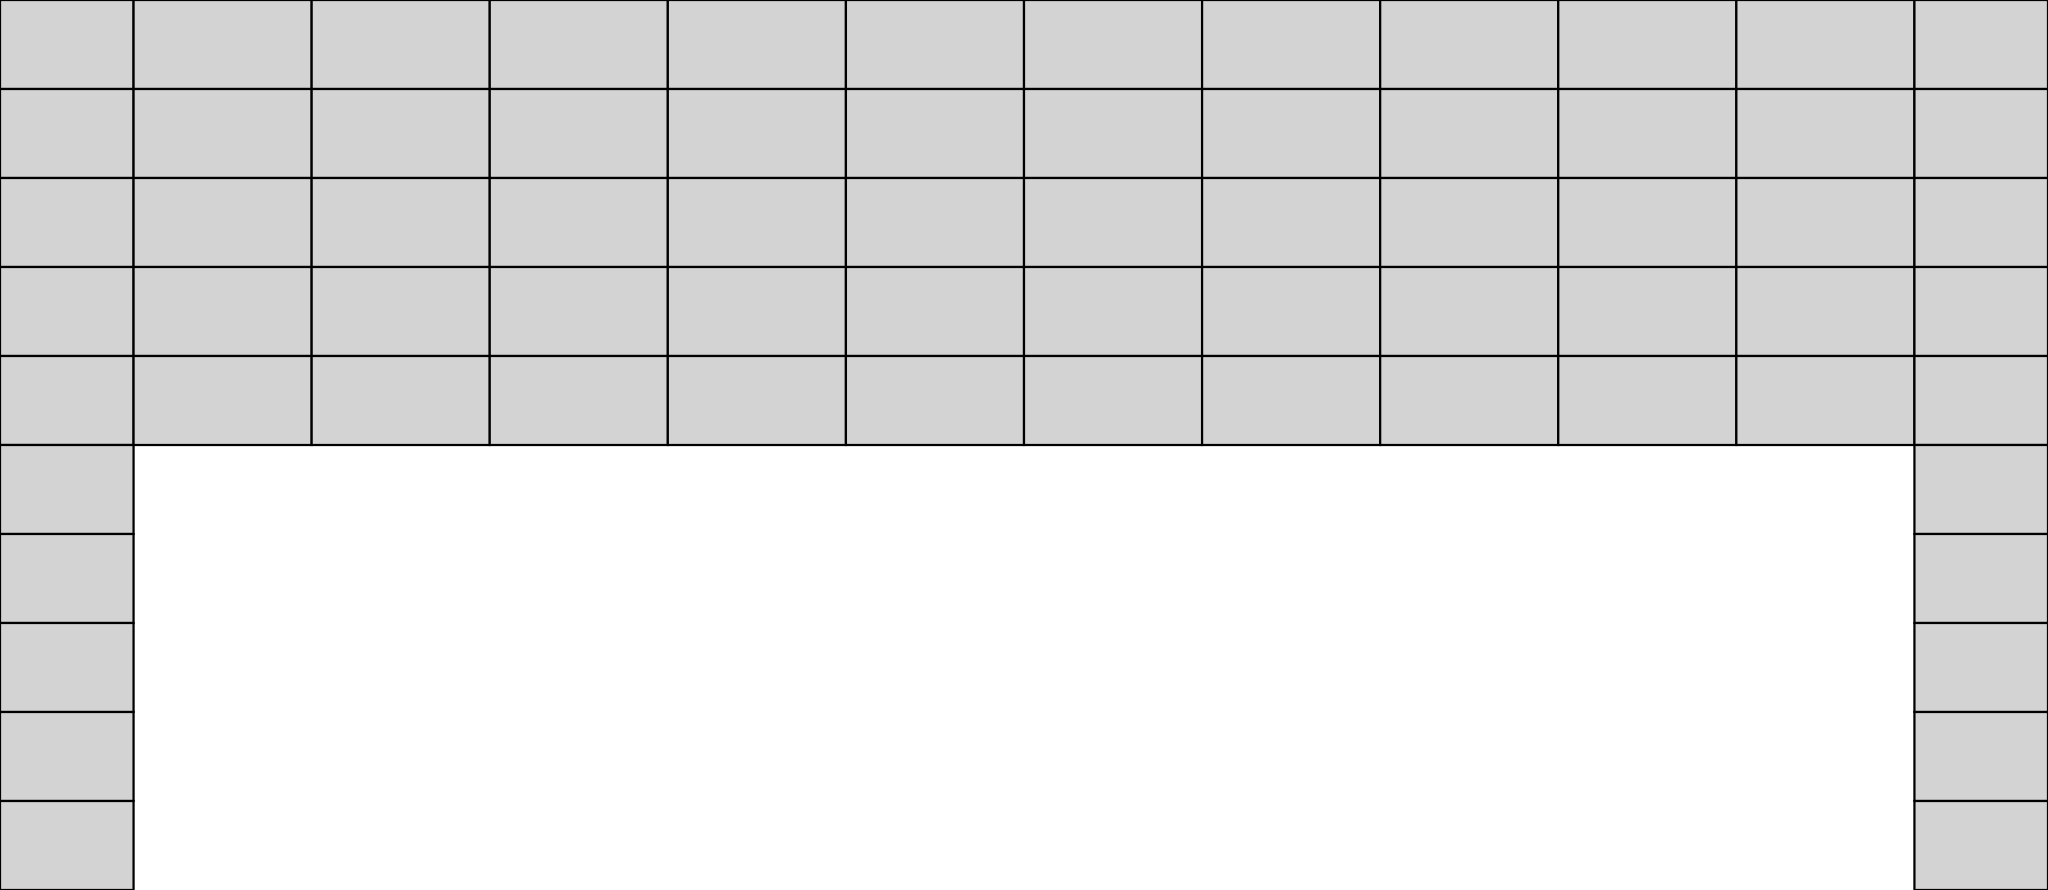

In [29]:
display_svg(fence_svg, settings)

In [21]:
column = draw_all_columns(
    fence_solution.column_blocks_per_column,
    fence_solution.columns_count,
    fence_solution.spans_length,
    column_block_30,
    xy
)

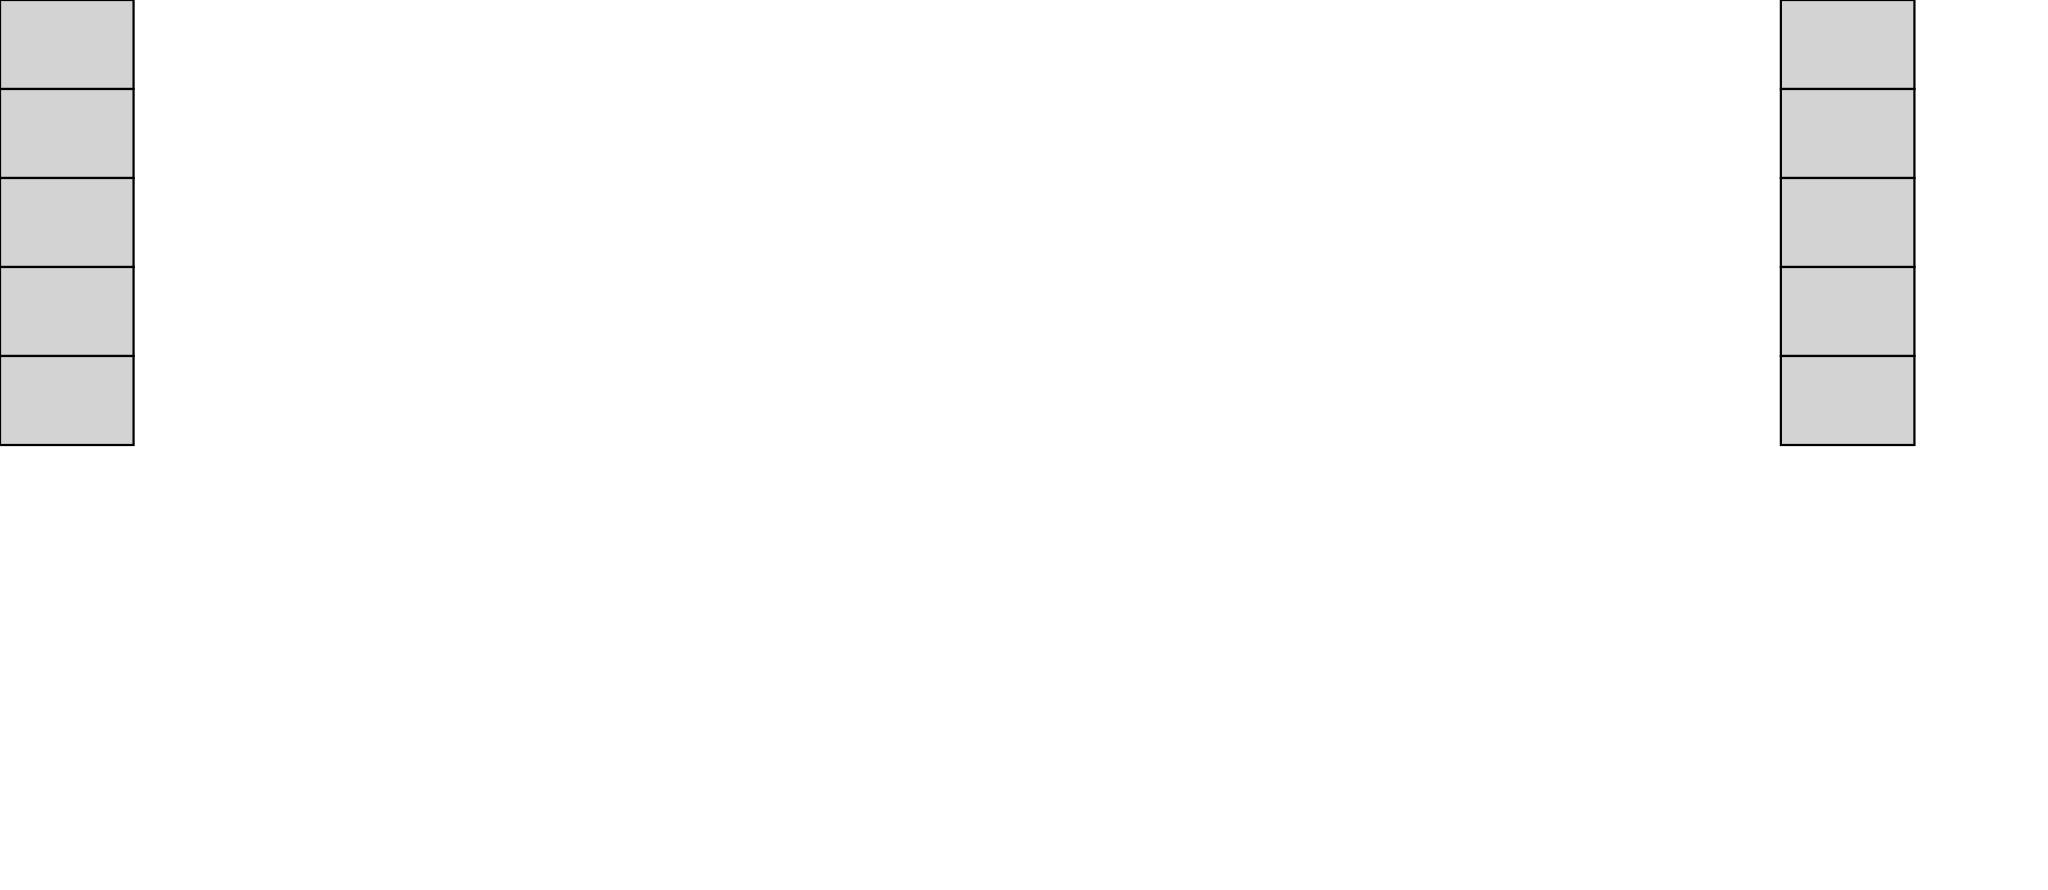

In [22]:
display_svg(column,settings)